In [1]:
import math
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import colormaps as cm
import matplotlib.dates as mdates

In [2]:
def load_model_prediction(config, eval_dates):
    """Loads prediction data based on the model's configuration."""
    pred_prefix = config["pred_prefix"]
    
    if pred_prefix == "persistence":
        num_missing_samples = config["num_missing_samples"] if config["num_missing_samples"] else 0
        return persistence_fcast(
            config["model_type"], config["run"], eval_dates, 
            num_missing_samples=num_missing_samples,
            fcast_nhours=config["duration"]
        )
    
    elif pred_prefix == "climatology":
        return climatology_fcast(
            config["model_type"], config["run"], eval_dates, 
            fcast_nhours=config["duration"]
        )
    
    elif pred_prefix == "graphufs":
        infer_dir = f"inference_{config['expt']}" if config["expt"] else "inference"
        location = os.path.join(SCRATCH_DIR, config["model_type"], config["run"], f"{infer_dir}/validation/")
        fname = f"{location}/{config['pred_prefix'].lower()}.{config['duration']}.zarr"
        model_pred = xr.open_zarr(fname)
        return model_pred.sel(time=slice(eval_dates[0], eval_dates[1]))
    
    else:
        raise ValueError(f"Unknown model type: {pred_prefix}")

In [3]:
def calculate_errors(model_pred, ref_truth):
    """
    Calculates the given metric against the reference truth.
    The metric parameter can take the following values: "SQE"/"ABS"/"DIFF"
    """
    # Create a land/sea mask based on the salinity field at the first time step
    mask = xr.where(ref_truth.so.isel(time=0, lead_time=0) == 0, 0, 1)
    
    error_vars = {}

    for var in model_pred.data_vars:
        # Determine the correct mask to use for this variable (with or without depth)
        current_mask = mask if "z_l" in model_pred[var].dims else mask.isel(z_l=0)
        
        # Compute error and apply mask
        error = (model_pred[var] - ref_truth[var]) * current_mask
        error_vars[var] = error
        
    return error_vars

In [4]:
def extract_forecasts(model_pred, ref_truth):
    """
    Extracts and masks the raw model forecasts for plotting (e.g. Hovmoller diagrams).
    Applies the same land/sea mask as calculate_errors for consistency.

    Parameters
    ----------
    model_pred : xr.Dataset  - model forecast fields
    ref_truth  : xr.Dataset  - reference truth (used only for masking)

    Returns
    -------
    forecast_vars : dict {var_name: xr.DataArray} with masked forecast fields
    """
    # Same land/sea mask as in calculate_errors
    mask = xr.where(ref_truth.so.isel(time=0, lead_time=0) == 0, 0, 1)

    forecast_vars = {}
    for var in model_pred.data_vars:
        current_mask = mask if "z_l" in model_pred[var].dims else mask.isel(z_l=0)
        forecast_vars[var] = model_pred[var] * current_mask

    return forecast_vars

# Config and Computation 

In [5]:
# ---- Config ----
TRUTHS = ["Replay"]
EVALUATION_DATES = ("2022-01-01T00", "2022-12-31T18")
FIG_DIR = os.path.join(os.getcwd(), "figures")
SCRATCH_DIR = "/pscratch/sd/n/nagarwal"
LEAD_TIME = 10 # in days

MODELS_CONFIG = [
    {
        "name": "Emulator-24h-MSE",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "T1M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay", 
        "timestep": "24h",
        "duration": "240h",
        "description": "24hour-mse"
    },
    {
        "name": "Emulator-24h-MLoss",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R8",
        "expt": "T2M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay",
        "timestep": "24h",
        "duration": "960h",
        "description": "24hour-maha"
    },
]

In [6]:
# ---- The Main Computation Block ----
# Initialize dictionaries to store all results
all_error = {}
all_model_forecasts = {}
all_ref_truth = {}
    
# Main loop over models
for model_config in MODELS_CONFIG:
    model_name = model_config["name"]
    print(f"Processing Model: {model_name}")
        
    all_error[model_name] = {}
    
    # Load the model prediction data once
    model_pred = load_model_prediction(model_config, EVALUATION_DATES)
        
    # Loop over the truth references for this model
    for truth_name in TRUTHS:
        print(f"Comparing against truth: {truth_name} ...")

        # Reference truth
        infer_dir = f"inference_{model_config['expt']}" if model_config["expt"] else "inference"
        location = os.path.join(SCRATCH_DIR, model_config['model_type'], 
                                model_config['run'], f"{infer_dir}/validation/")
        fname = f"{location}/{truth_name.lower()}.{model_config['duration']}.zarr"
        ref_truth = xr.open_zarr(fname)
            
        # Compute and store the error
        error = calculate_errors(model_pred, ref_truth)
        all_error[model_name][truth_name] = error

        # Process and store forecasts
        # Reference truth
        if truth_name not in all_ref_truth.keys():
            all_ref_truth[truth_name] = extract_forecasts(ref_truth, ref_truth)
        all_model_forecasts[model_name] = extract_forecasts(model_pred, ref_truth)
        
print("\n--- Metric calculation complete!! ---")

Processing Model: Emulator-24h-MSE
Comparing against truth: Replay ...
Processing Model: Emulator-24h-MLoss
Comparing against truth: Replay ...

--- Metric calculation complete!! ---


# Plot Hovmoller diagram

In [7]:
def plot_hovmoller_error(
    data_dict: dict,
    var_name: str,
    truth: str,
    models_config: list,
    vert_level_idx: int,
    lead_time_idx: int,
    lat_range: tuple = (-1, 5),
    lon_range: tuple = (180, 270),       # 270°E = 90°W
    period: tuple = ("2022-08-01", "2022-11-30"),
    vmax: float = None,
    cmap: str = "RdBu_r",
    var_print_name: str = None,
    unit: str = None,
):
    """
    Plot Hovmoller (longitude x time) diagrams of forecast errors for each model.

    Parameters
    ----------
    data_dict     : nested dict [model_name][truth][var_name] -> xr.DataArray(lat, lon, time, lead_time)
    var_name      : variable to plot
    truth         : reference truth key
    models_config : list of model config dicts with at least a "name" key
    vert_level_idx: vertical level index (0 corresponds to surface)
    lead_time_idx : index along lead_time dimension to select
    lat_range     : (lat_min, lat_max) for equatorial band, default (-1, 5)
    lon_range     : (lon_min, lon_max) in 0-360°E, default (180, 270)
    period        : range of initial condition dates to plot
    vmax          : colorbar symmetric limit; auto-computed if None
    cmap          : colormap, default 'RdBu_r'
    """
    n_models = len(models_config)
    fig, axes = plt.subplots(1, n_models, figsize=(5.5 * n_models, 7), sharey=True)

    if n_models == 1:
        axes = [axes]

    for ax, config in zip(axes, models_config):
        model_name = config["name"]

        # --- 1. Select lead time and crop to region + time period ---
        err = (
            data_dict[model_name][truth][var_name]
            .isel(z_l=vert_level_idx,
                  lead_time=lead_time_idx)
            .sel(
                lat=slice(*lat_range),
                lon=slice(*lon_range),
                time=slice(*period),
            )
        )

        # --- 2. Collapse latitude (mean over equatorial band) ---
        err_hovmoller = err.mean("lat")  # (lon, time)
        print("RMSE Error in the Hovmoller = ", np.sqrt(np.mean(err_hovmoller.values**2)))

        # --- 3. Compute symmetric colorbar limits if not provided ---
        clim = vmax or float(np.abs(err_hovmoller).compute().max())

        # --- 4. Plot ---
        pm = ax.pcolormesh(
            err_hovmoller.lon.values,
            err_hovmoller.time.values,
            err_hovmoller.values,
            cmap=cmap,
            vmin=-clim,
            vmax=clim,
        )
        
        ax.set_title(model_name, fontsize=13)
        ax.set_xlabel("Longitude (°E)")
        ax.set_ylabel("Initialization Date" if ax == axes[0] else "")

        # Convert x-axis to °W labels for readability
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{int(360 - x)}°W" if x > 180 else f"{int(x)}°E")
        )

    # Plot a single colorbar
    cbar_label = "Error"
    if unit:
        cbar_label += f" [{unit}]" 
    fig.subplots_adjust(right=0.88, wspace=0.1)
    cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    fig.colorbar(pm, cax=cbar_ax, label=cbar_label)
    
    axes[0].invert_yaxis() # time is generally increasing from top to bottom in Hovmoller
    axes[0].yaxis.set_major_locator(mdates.MonthLocator())
    axes[0].yaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

    var_name_title = var_print_name if var_print_name is not None else var_name 
    fig.suptitle(f"Forecat Error Hovmöller — {var_name_title}", fontsize=15)
    # plt.tight_layout()
    plt.show()

    return fig

In [8]:
def plot_hovmoller_forecast(
    data_dict: dict,
    var_name: str,
    models_config: list,
    ref_forecasts: dict,
    vert_level_idx: int,
    lead_time_idx: int,
    lat_range: tuple = (-1, 5),
    lon_range: tuple = (180, 270),
    period: tuple = ("2022-08-01", "2022-11-30"),
    vmin: float = None,
    vmax: float = None,
    cmap: str = "viridis",
    remove_time_mean: bool = False,
    climatology_period: tuple = ("2022-01-01", "2022-12-31"),
    overlay_contours: bool = False,
    contour_levels: list = None,
    var_print_name: str = None,
    unit: str = None,
):
    n_models = len(models_config)
    n_cols = n_models + 1
    fig, axes = plt.subplots(1, n_cols, figsize=(5.5 * n_cols, 7), sharey=True)

    def _compute_mean(da):
        isel_kwargs = dict(lead_time=lead_time_idx)
        if "z_l" in da.dims:
            isel_kwargs["z_l"] = vert_level_idx
        return (
            da.isel(**isel_kwargs)
            .sel(lat=slice(*lat_range), lon=slice(*lon_range), time=slice(*climatology_period))
            .mean("time")
            .compute()
        )

    def _prepare(da):
        isel_kwargs = dict(lead_time=lead_time_idx)
        if "z_l" in da.dims:
            isel_kwargs["z_l"] = vert_level_idx
        result = (
            da.isel(**isel_kwargs)
            .sel(lat=slice(*lat_range), lon=slice(*lon_range), time=slice(*period))
        )
        if remove_time_mean:
            result = result - _compute_mean(da)
        return result.mean("lat").compute()

    # --- Pre-compute all panels ---
    hovmollers = [_prepare(data_dict[c["name"]][var_name]) for c in models_config]
    hovmollers.append(_prepare(ref_forecasts[var_name]))

    clim_min = vmin if vmin is not None else min(float(h.min()) for h in hovmollers)
    clim_max = vmax if vmax is not None else max(float(h.max()) for h in hovmollers)

    if remove_time_mean:
        cmap = cmap if cmap != "viridis" else "RdBu_r"
        clim_max = vmax or max(abs(clim_min), abs(clim_max))
        clim_min = -clim_max

    # --- Derive contour levels from reference truth (last panel) ---
    if overlay_contours:
        ref_hov = hovmollers[-1]
        levels = contour_levels or np.linspace(
            float(ref_hov.min()), float(ref_hov.max()), n_contours + 2
        )[1:-1]  # drop outermost to avoid edge artifacts

    # --- Plot ---
    labels = [c["name"] for c in models_config] + ["Reference Truth - Replay"]
    for ax, hov, label in zip(axes, hovmollers, labels):
        pm = ax.pcolormesh(
            hov.lon.values,
            hov.time.values,
            hov.values,
            cmap=cmap,
            vmin=clim_min,
            vmax=clim_max,
        )
        ax.set_title(label, fontsize=13, pad=10)

        if overlay_contours:
            cs = ax.contour(
                hov.lon.values,
                hov.time.values,
                hov.values,
                levels=contour_levels,
                colors="w",
                linewidths=0.8,
                linestyles="solid",
            )
            ax.clabel(cs, fmt="%.1f", fontsize=7, inline=True)

        ax.set_xlabel("Longitude (°E)")
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{int(360 - x)}°W" if x > 180 else f"{int(x)}°E")
        )

    # --- Post-loop: shared colorbar, y-axis, invert ---
    var_print = var_print_name if var_print_name else var_name
    cbar_label = f"{var_print} anomaly" if remove_time_mean else var_print
    if unit:
        cbar_label += f" [{unit}]" 
    fig.subplots_adjust(right=0.88, wspace=0.1)
    cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    fig.colorbar(pm, cax=cbar_ax, label=cbar_label)

    axes[0].invert_yaxis()  # invert once; sharey propagates to all
    axes[0].yaxis.set_major_locator(mdates.MonthLocator())
    axes[0].yaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    axes[0].set_ylabel("Initialization Date")

    title_suffix = f" (anomaly, mean removed over {climatology_period[0][:4]})" if remove_time_mean else ""
    title = f"Forecast Hovmöller — {var_print}{title_suffix}"
    fig.suptitle(title, fontsize=15)

    #plt.tight_layout()
    plt.show()
    return fig

# Hovmoller of forecast errors

RMSE Error in the Hovmoller =  0.1135902277653748
RMSE Error in the Hovmoller =  0.3129153042538239


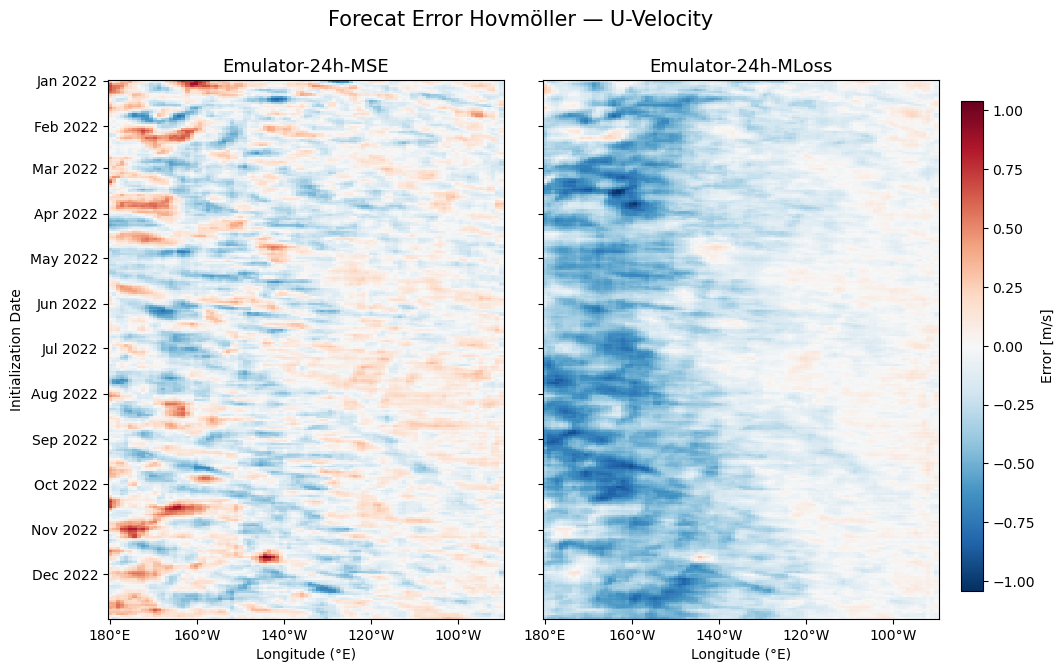

In [9]:
# Plot the Hovmoller diagram to visualize TIWs around the equator.
lat_range = (1, -1) # latitude range
lon_range = (180, 270)
period = ("2022-01-01", "2022-12-31")
vert_level_idx = 4
var_name = "uo"
truth = "Replay"
vmax=None
var_print_name = "U-Velocity"
unit = "m/s"
save_plot = False

hv_err = plot_hovmoller_error(
    all_error,
    var_name=var_name,
    truth=truth,
    models_config=MODELS_CONFIG,
    vert_level_idx=vert_level_idx, 
    lead_time_idx=LEAD_TIME - 1,
    lat_range=lat_range,
    lon_range=lon_range,
    period=period,
    vmax=vmax,
    var_print_name = var_print_name,
    unit = unit,
)

if save_plot:
    hv_err.savefig(f"figures/fcast_error_hovmoller_{var_name}_level-{vert_level_idx}_{LEAD_TIME}day_forecasts_MSE_M-Loss_wrt_Replay_Reference.png", dpi=300)

# Hovmoller for the actual forecasts

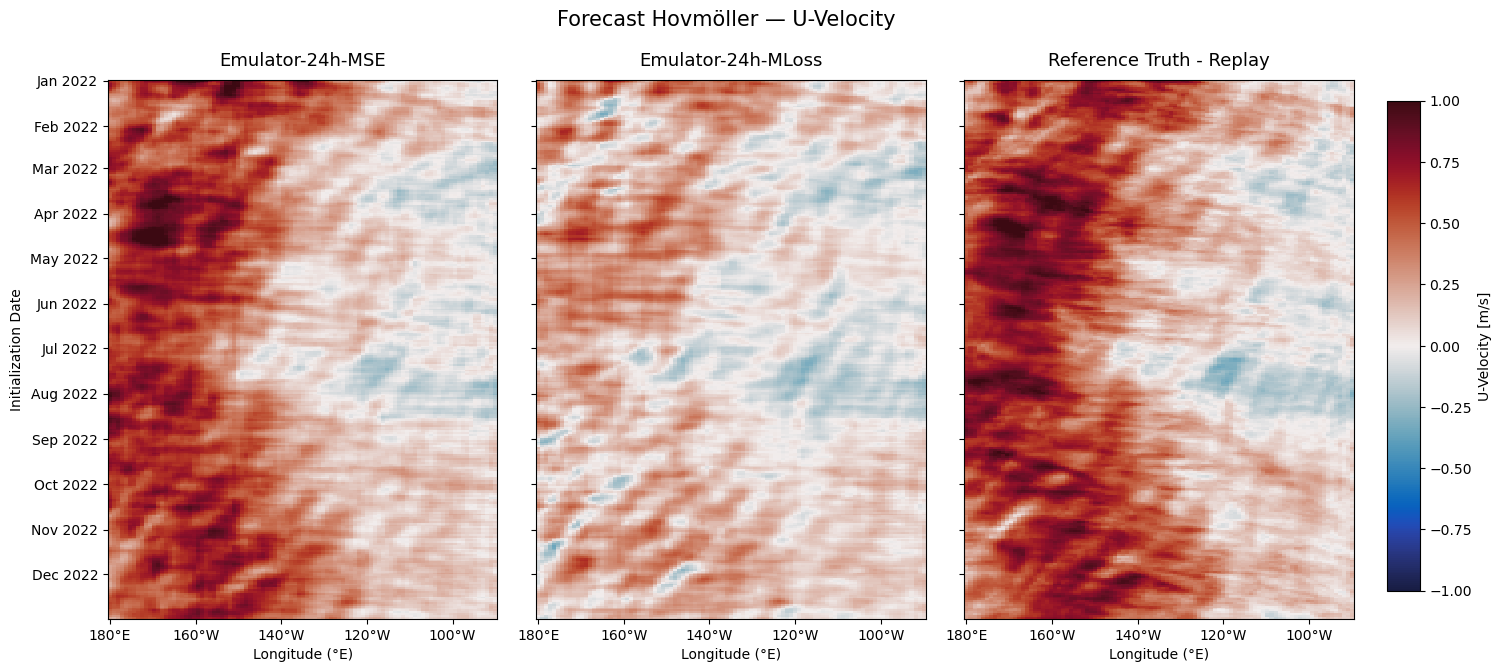

In [10]:
# Plot the Hovmoller diagram to visualize TIWs around the equator.
lat_range = (1, -1) # latitude range
lon_range = (180, 270)
period = ("2022-01-01", "2022-12-31")
vert_level_idx = 4
var_name = "uo" # "so"
truth = "Replay"
vmin= -1 # sst: 22, sss: 33.4
vmax= 1 # sst0: 30, sss: 35.4
cmap= cm.balance # sst: cm.thermal, sss: cm.haline, uo/vo: cm.balance
remove_time_mean = False
mean_period = ("2022-01-01", "2022-12-31")
overlay_contours=False
contour_levels = None # sst: [24,26], sss: [34, 34.8]
var_print_name =  "U-Velocity" # "Sea Surface Salinity"
unit = "m/s" # "psu"
save_plot = False

hv = plot_hovmoller_forecast(
        all_model_forecasts,
        var_name=var_name,
        models_config=MODELS_CONFIG,
        ref_forecasts=all_ref_truth[truth],
        vert_level_idx=vert_level_idx, 
        lead_time_idx=LEAD_TIME - 1,
        lat_range=lat_range,
        lon_range=lon_range,
        period=period,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        remove_time_mean=remove_time_mean,
        climatology_period=mean_period,
        overlay_contours=overlay_contours,
        contour_levels=contour_levels,
        var_print_name = var_print_name,
        unit=unit,
)

if save_plot:
    hv.savefig(f"figures/hovmoller_{var_name}_level-{vert_level_idx}_{LEAD_TIME}day_forecasts_MSE_M-Loss_Replay_Reference.png", dpi=300)

In [17]:
all_error["Emulator-24h-MLoss"]['Replay']['uo'].z_l.values

array([  0.51540376,  11.06225874,  47.20506573,  93.66578484,
       152.09254646, 271.22279739, 417.70420074])